In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import brier_score_loss
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve
from sklearn.metrics import log_loss
from sklearn.calibration import CalibrationDisplay
from sklearn.tree import DecisionTreeClassifier

In [ ]:
safe = pd.read_excel("/content/safe_data.xlsx")
safe.head()

,stock_code,company_name,year,establish_year,total_asset,total_debt,current_debt,total_equity,revenue,opex,retained_profit
0,CVT,CTCP CMC,2021,1958,2427738320582,1650188457833,937601996499,777549862749,1519086060089,8.061484e+10,94195469045
1,CVT,CTCP CMC,2022,1958,3372478210996,2500760097868,1318754778696,871718113128,2065191370532,1.352758e+11,94946367014
2,CVT,CTCP CMC,2023,1958,3311682742724,2400165710598,1381842265456,911517032126,2002486096252,1.586219e+11,40619518535
3,DBT,CTCP Dược phẩm Bến Tre,2021,1983,786991797262,587435154059,568540681308,199556643203,633963024056,1.733723e+11,12745322645
4,DBT,CTCP Dược phẩm Bến Tre,2022,1983,840719747340,616426857523,600017617474,224242889817,755855570573,2.150331e+11,40500398144


In [ ]:
print(safe.isnull().sum())

stock_code         0
company_name       0
year               0
establish_year     0
total_asset        0
total_debt         0
current_debt       0
total_equity       1
revenue            0
opex               0
retained_profit    0
dtype: int64


In [ ]:
safe = safe.dropna()
print(safe.isnull().sum())

stock_code         0
company_name       0
year               0
establish_year     0
total_asset        0
total_debt         0
current_debt       0
total_equity       0
revenue            0
opex               0
retained_profit    0
dtype: int64


In [ ]:
safe.dtypes

,0
stock_code,object
company_name,object
year,int64
establish_year,int64
total_asset,object
total_debt,int64
current_debt,int64
total_equity,object
revenue,int64
opex,float64


In [ ]:
cols_to_convert = ["total_asset", "total_equity"]  # Danh sách các cột cần chuyển đổi

for col in cols_to_convert:
    safe[col] = pd.to_numeric(safe[col], errors="coerce")  # Chuyển đổi, nếu lỗi thì thành NaN

print(safe.dtypes)  # Kiểm tra lại kiểu dữ liệu sau khi chuyển đổi

stock_code          object
company_name        object
year                 int64
establish_year       int64
total_asset        float64
total_debt           int64
current_debt         int64
total_equity       float64
revenue              int64
opex               float64
retained_profit      int64
dtype: object


<ipython-input-135-141978ac5b7c>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  safe[col] = pd.to_numeric(safe[col], errors="coerce")  # Chuyển đổi, nếu lỗi thì thành NaN


In [ ]:
risk = pd.read_excel("/content/risk_data.xlsx")
risk.head()

,stock_code,company_name,year,establish_year,total_asset,total_debt,current_debt,total_equity,revenue,opex,retained_profit
0,ABS,CTCP Dịch vụ Nông nghiệp Bình Thuận,2021,1975,1592951748069,666547625424,666155125424,926404122645,1.198699e+12,15759326761,65351945620
1,ABS,CTCP Dịch vụ Nông nghiệp Bình Thuận,2022,1975,1669271116551,763594899943,762417399943,905676216608,1.605396e+12,20082649703,22539691244
2,ABS,CTCP Dịch vụ Nông nghiệp Bình Thuận,2023,1975,1579205344498,665242118219,664304618219,913963226279,1.025223e+12,44618389392,8287009671
3,ADG,CTCP Clever Group,2021,2008,449600789258,180148111893,177907103818,269452677364,5.859314e+11,38379767956,38665781450
4,ADG,CTCP Clever Group,2022,2008,409722656773,84998068448,82180916257,324724588325,5.368315e+11,45850612282,52682672025


In [ ]:
print(risk.isnull().sum())

stock_code         0
company_name       0
year               0
establish_year     0
total_asset        0
total_debt         0
current_debt       0
total_equity       0
revenue            0
opex               0
retained_profit    0
dtype: int64


In [ ]:
risk.dtypes

,0
stock_code,object
company_name,object
year,int64
establish_year,int64
total_asset,int64
total_debt,int64
current_debt,int64
total_equity,int64
revenue,float64
opex,int64


In [ ]:
cols_to_convert = ["retained_profit"]  # Danh sách các cột cần chuyển đổi

for col in cols_to_convert:
    risk[col] = pd.to_numeric(risk[col], errors="coerce")  # Chuyển đổi, nếu lỗi thì thành NaN

print(safe.dtypes)  # Kiểm tra lại kiểu dữ liệu sau khi chuyển đổi

stock_code          object
company_name        object
year                 int64
establish_year       int64
total_asset        float64
total_debt           int64
current_debt         int64
total_equity       float64
revenue              int64
opex               float64
retained_profit      int64
dtype: object


In [ ]:
df_combined = pd.concat([risk, safe], ignore_index=True) #gộp 2 bảng lại thành dữ liệu tổng
df_combined.head()

,stock_code,company_name,year,establish_year,total_asset,total_debt,current_debt,total_equity,revenue,opex,retained_profit
0,ABS,CTCP Dịch vụ Nông nghiệp Bình Thuận,2021,1975,1.592952e+12,666547625424,666155125424,9.264041e+11,1.198699e+12,1.575933e+10,6.535195e+10
1,ABS,CTCP Dịch vụ Nông nghiệp Bình Thuận,2022,1975,1.669271e+12,763594899943,762417399943,9.056762e+11,1.605396e+12,2.008265e+10,2.253969e+10
2,ABS,CTCP Dịch vụ Nông nghiệp Bình Thuận,2023,1975,1.579205e+12,665242118219,664304618219,9.139632e+11,1.025223e+12,4.461839e+10,8.287010e+09
3,ADG,CTCP Clever Group,2021,2008,4.496008e+11,180148111893,177907103818,2.694527e+11,5.859314e+11,3.837977e+10,3.866578e+10
4,ADG,CTCP Clever Group,2022,2008,4.097227e+11,84998068448,82180916257,3.247246e+11,5.368315e+11,4.585061e+10,5.268267e+10


In [ ]:
df_combined.dtypes

,0
stock_code,object
company_name,object
year,int64
establish_year,int64
total_asset,float64
total_debt,int64
current_debt,int64
total_equity,float64
revenue,float64
opex,float64


In [ ]:
print(df_combined.isnull().sum())

stock_code         0
company_name       0
year               0
establish_year     0
total_asset        1
total_debt         0
current_debt       0
total_equity       1
revenue            0
opex               0
retained_profit    1
dtype: int64


In [ ]:
df_combined = df_combined.dropna()

In [ ]:
# Tính toán các chỉ số tài chính
# Đòn bẩy tài chính
df_combined['fin_leverage'] = df_combined['total_debt']/df_combined['total_asset']

# Quy mô doanh nghiệp
import numpy as np
df_combined['enterprise_size'] = np.log(df_combined['total_asset'])

# Khả năng sinh lời
df_combined['earnings_power'] = df_combined['retained_profit']/df_combined['total_asset']

# Số năm hoạt động
df_combined['years_of_operation'] = df_combined['year'] - df_combined['establish_year']

# Lạm phát
df_combined.loc[df_combined['year'] == 2023, 'inflation'] = 0.0325
df_combined.loc[df_combined['year'] == 2022, 'inflation'] = 0.0315
df_combined.loc[df_combined['year'] == 2021, 'inflation'] = 0.0184

# GDP
df_combined.loc[df_combined['year'] == 2023, 'gdp_gr'] = 0.0505
df_combined.loc[df_combined['year'] == 2022, 'gdp_gr'] = 0.0802
df_combined.loc[df_combined['year'] == 2021, 'gdp_gr'] = 0.0258


df_combined.head()

<ipython-input-144-9f24145aaa70>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_combined['fin_leverage'] = df_combined['total_debt']/df_combined['total_asset']
<ipython-input-144-9f24145aaa70>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_combined['enterprise_size'] = np.log(df_combined['total_asset'])
<ipython-input-144-9f24145aaa70>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cav

,stock_code,company_name,year,establish_year,total_asset,total_debt,current_debt,total_equity,revenue,opex,retained_profit,fin_leverage,enterprise_size,earnings_power,years_of_operation,inflation,gdp_gr
0,ABS,CTCP Dịch vụ Nông nghiệp Bình Thuận,2021,1975,1.592952e+12,666547625424,666155125424,9.264041e+11,1.198699e+12,1.575933e+10,6.535195e+10,0.418436,28.096610,0.041026,46,0.0184,0.0258
1,ABS,CTCP Dịch vụ Nông nghiệp Bình Thuận,2022,1975,1.669271e+12,763594899943,762417399943,9.056762e+11,1.605396e+12,2.008265e+10,2.253969e+10,0.457442,28.143408,0.013503,47,0.0315,0.0802
2,ABS,CTCP Dịch vụ Nông nghiệp Bình Thuận,2023,1975,1.579205e+12,665242118219,664304618219,9.139632e+11,1.025223e+12,4.461839e+10,8.287010e+09,0.421251,28.087943,0.005248,48,0.0325,0.0505
3,ADG,CTCP Clever Group,2021,2008,4.496008e+11,180148111893,177907103818,2.694527e+11,5.859314e+11,3.837977e+10,3.866578e+10,0.400685,26.831626,0.086000,13,0.0184,0.0258
4,ADG,CTCP Clever Group,2022,2008,4.097227e+11,84998068448,82180916257,3.247246e+11,5.368315e+11,4.585061e+10,5.268267e+10,0.207453,26.738746,0.128581,14,0.0315,0.0802


In [ ]:
df_combined.dtypes

,0
stock_code,object
company_name,object
year,int64
establish_year,int64
total_asset,float64
total_debt,int64
current_debt,int64
total_equity,float64
revenue,float64
opex,float64


In [ ]:
df_combined.describe()

,year,establish_year,total_asset,total_debt,current_debt,total_equity,revenue,opex,retained_profit,fin_leverage,enterprise_size,earnings_power,years_of_operation,inflation,gdp_gr
count,1070.00000,1070.000000,1.070000e+03,1.070000e+03,1.070000e+03,1.070000e+03,1.070000e+03,1.070000e+03,1.070000e+03,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,2022.00000,1993.228972,4.893157e+13,4.106226e+13,3.951505e+13,7.925103e+12,7.874754e+12,1.129586e+12,9.383994e+11,0.480697,28.817956,0.047484,28.771028,0.027463,0.052140
std,0.81726,16.138285,2.162956e+14,1.964648e+14,1.960430e+14,2.880082e+13,1.921898e+13,3.473804e+12,3.459184e+12,0.240468,1.932221,0.094512,16.158965,0.006429,0.022244
min,2021.00000,1875.000000,1.266985e+10,1.257855e+09,1.257855e+09,-1.702593e+13,0.000000e+00,-1.383388e+11,-1.327899e+13,0.000247,23.262491,-0.831684,3.000000,0.018400,0.025800
25%,2021.00000,1985.000000,9.767918e+11,3.066993e+11,1.997576e+11,4.751396e+11,4.777218e+11,3.696823e+10,1.799178e+10,0.284287,27.607539,0.010213,18.000000,0.018400,0.025800
50%,2022.00000,1998.000000,2.157642e+12,9.758968e+11,7.409790e+11,1.137452e+12,1.327317e+12,1.141604e+11,8.139705e+10,0.485290,28.400022,0.033865,24.000000,0.031500,0.050500
75%,2023.00000,2004.000000,7.608251e+12,4.326058e+12,3.091193e+12,3.572513e+12,4.904866e+12,4.203316e+11,3.345083e+11,0.660456,29.660252,0.084542,37.000000,0.032500,0.080200
max,2023.00000,2018.000000,2.300869e+15,2.178002e+15,2.178002e+15,5.703467e+14,1.614528e+14,3.094437e+13,3.452095e+13,1.294990,35.372063,1.123569,148.000000,0.032500,0.080200


In [ ]:
print(df_combined.isnull().sum())

stock_code            0
company_name          0
year                  0
establish_year        0
total_asset           0
total_debt            0
current_debt          0
total_equity          0
revenue               0
opex                  0
retained_profit       0
fin_leverage          0
enterprise_size       0
earnings_power        0
years_of_operation    0
inflation             0
gdp_gr                0
dtype: int64


In [ ]:
risky_list_2023 = ['ABS','ADG','ADP','AGM','APC','APH','ASG','ASP','AST','BCE','CIG','CKG','DAG','DAH','DC4','DLG','DRH','DTL','DXS','DXV','EVG','FDC','FRT','GIL','GMC','HAG','HAS','HBC','HID','HNG','HPX','HSG','HT1','HVN','HVX','IBC','ITA','JVC','LDG','LEC','LGL','MHC','NVL','NVT','OGC','PIT','PLP','PMG','POM','PPC','PTC','PTL','QBS','QCG','RDP','SBV','SCD','SIP','SJF','SMA','SMC','SPM','SRF','SVD','TCR','TDC','TDH','TGG','TNA','TNI','TPC','TSC','TTB','TTE','TTF','TVB','TYA','VJC','VMD']
df_combined['label_2023'] = ((df_combined['stock_code'].isin(risky_list_2023)) & (df_combined['year'] == 2023)).astype(int) #kiểm tra xem mã cổ phiếu có nằm trong danh sách rủi ro hay có thuộc năm 2023 không?
df_combined.head()

,stock_code,company_name,year,establish_year,total_asset,total_debt,current_debt,total_equity,revenue,opex,retained_profit,fin_leverage,enterprise_size,earnings_power,years_of_operation,inflation,gdp_gr,label_2023
0,ABS,CTCP Dịch vụ Nông nghiệp Bình Thuận,2021,1975,1.592952e+12,666547625424,666155125424,9.264041e+11,1.198699e+12,1.575933e+10,6.535195e+10,0.418436,28.096610,0.041026,46,0.0184,0.0258,0
1,ABS,CTCP Dịch vụ Nông nghiệp Bình Thuận,2022,1975,1.669271e+12,763594899943,762417399943,9.056762e+11,1.605396e+12,2.008265e+10,2.253969e+10,0.457442,28.143408,0.013503,47,0.0315,0.0802,0
2,ABS,CTCP Dịch vụ Nông nghiệp Bình Thuận,2023,1975,1.579205e+12,665242118219,664304618219,9.139632e+11,1.025223e+12,4.461839e+10,8.287010e+09,0.421251,28.087943,0.005248,48,0.0325,0.0505,1
3,ADG,CTCP Clever Group,2021,2008,4.496008e+11,180148111893,177907103818,2.694527e+11,5.859314e+11,3.837977e+10,3.866578e+10,0.400685,26.831626,0.086000,13,0.0184,0.0258,0
4,ADG,CTCP Clever Group,2022,2008,4.097227e+11,84998068448,82180916257,3.247246e+11,5.368315e+11,4.585061e+10,5.268267e+10,0.207453,26.738746,0.128581,14,0.0315,0.0802,0


In [ ]:
df_combined.to_excel("to_stata_data_label.xlsx", index=False)

In [ ]:
#Kiểm tra zố dòng trùng lặp theo Stock_code và Year
df_combined.duplicated(subset=['stock_code', 'year']).sum()
df_combined[df_combined.duplicated(subset=['stock_code', 'year'], keep=False)] # 50 duplicated data

,stock_code,company_name,year,establish_year,total_asset,total_debt,current_debt,total_equity,revenue,opex,retained_profit,fin_leverage,enterprise_size,earnings_power,years_of_operation,inflation,gdp_gr,label_2023
6,ADP,CTCP Sơn Á Đông,2021,1970,3.309302e+11,52864665516,52864665516,2.780656e+11,4.163541e+11,3.550573e+10,4.958364e+10,0.159746,26.525173,0.149831,51,0.0184,0.0258,0
7,ADP,CTCP Sơn Á Đông,2022,1970,3.585034e+11,84167434784,84167434784,2.743360e+11,5.891196e+11,4.676561e+10,4.004614e+10,0.234774,26.605204,0.111704,52,0.0315,0.0802,0
8,ADP,CTCP Sơn Á Đông,2023,1970,3.813286e+11,94138398232,94138398232,2.871902e+11,5.191380e+11,3.582931e+10,5.893403e+10,0.246869,26.666927,0.154549,53,0.0325,0.0505,1
9,AGM,CTCP Xuất Nhập khẩu An Giang,2021,1976,1.856416e+12,1373757471254,1029553766087,4.826586e+11,3.931418e+12,2.124066e+11,4.471247e+10,0.740005,28.249669,0.024085,45,0.0184,0.0258,0
10,AGM,CTCP Xuất Nhập khẩu An Giang,2022,1976,1.580799e+12,1288785900554,1028891503676,2.920133e+11,3.432577e+12,3.422384e+11,-2.329828e+11,0.815275,28.088952,-0.147383,46,0.0315,0.0802,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035,VCB,Ngân hàng Thương mại cổ phần Ngoại thương Việt...,2022,1963,1.813815e+15,1243468471000000,1243468471000000,5.703467e+14,8.811270e+13,2.125051e+13,2.991905e+13,0.685554,35.134209,0.016495,59,0.0315,0.0802,0
1036,VCB,Ngân hàng Thương mại cổ phần Ngoại thương Việt...,2023,1963,1.839613e+15,1674600532000000,1674600532000000,1.650127e+14,1.081223e+14,2.191490e+13,3.305445e+13,0.910300,35.148332,0.017968,60,0.0325,0.0505,0
1043,ADP,CTCP Sơn Á Đông,2021,1970,3.309302e+11,52864665516,52864665516,2.780656e+11,4.163541e+11,3.550573e+10,4.958364e+10,0.159746,26.525173,0.149831,51,0.0184,0.0258,0
1044,ADP,CTCP Sơn Á Đông,2022,1970,3.585034e+11,84167434784,84167434784,2.743360e+11,5.191380e+11,4.676561e+10,4.004614e+10,0.234774,26.605204,0.111704,52,0.0315,0.0802,0


In [ ]:
# Xóa các dòng trùng lặp theo stock_code và year, chỉ giữ lại một dòng
df_combined = df_combined.drop_duplicates(subset=['stock_code', 'year'], keep='first').reset_index(drop=True)

In [ ]:
print(df_combined.duplicated(subset=['stock_code', 'year']).sum())  # Kết quả phải là 0

0


In [ ]:
# chuyển lag
df_pivoted = df_combined.pivot_table(index=["stock_code", "company_name","establish_year"], columns="year")

# Đổi tên cột để dễ hiểu (tạo lag)
df_pivoted.columns = [f"{var}_lag{2023 - year}" for var, year in df_pivoted.columns]

# Reset index để đưa "stock_code" và "company_name" trở lại thành cột
df_pivoted.reset_index(inplace=True)

# Xem kết quả
df_data = pd.DataFrame(df_pivoted)
df_data.head()

,stock_code,company_name,establish_year,current_debt_lag2,current_debt_lag1,current_debt_lag0,earnings_power_lag2,earnings_power_lag1,earnings_power_lag0,enterprise_size_lag2,...,total_asset_lag0,total_debt_lag2,total_debt_lag1,total_debt_lag0,total_equity_lag2,total_equity_lag1,total_equity_lag0,years_of_operation_lag2,years_of_operation_lag1,years_of_operation_lag0
0,AAA,CTCP Nhựa An Phát Xanh,2002,3.282339e+12,3.206483e+12,3.737041e+12,0.032383,0.010864,0.026693,29.934558,...,1.158345e+13,4.555145e+12,4.624647e+12,5.619575e+12,5.454382e+12,6.171185e+12,5.963871e+12,19.0,20.0,21.0
1,AAM,CTCP Thủy sản Mekong,1979,5.544333e+09,7.937232e+09,9.148047e+09,0.001121,0.077316,0.003303,26.027006,...,2.128573e+11,6.761018e+09,9.043272e+09,1.022154e+10,1.943265e+11,2.095363e+11,2.026358e+11,42.0,43.0,44.0
2,AAT,CTCP Tập Đoàn Tiên Sơn Thanh Hóa,1995,1.157017e+11,2.127417e+11,2.282227e+11,0.029504,0.084511,-0.002709,27.607356,...,1.011341e+12,3.078756e+11,3.219638e+11,3.039931e+11,6.687368e+11,7.314821e+11,7.073479e+11,26.0,27.0,28.0
3,ABS,CTCP Dịch vụ Nông nghiệp Bình Thuận,1975,6.661551e+11,7.624174e+11,6.643046e+11,0.041026,0.013503,0.005248,28.096610,...,1.579205e+12,6.665476e+11,7.635949e+11,6.652421e+11,9.264041e+11,9.056762e+11,9.139632e+11,46.0,47.0,48.0
4,ABT,CTCP Xuất nhập khẩu Thủy sản Bến Tre,1977,1.715080e+11,1.480662e+11,1.574554e+11,0.056865,0.103269,0.098055,27.110606,...,6.513844e+11,1.756783e+11,1.516484e+11,1.605650e+11,4.185957e+11,4.708915e+11,4.908194e+11,44.0,45.0,46.0


In [ ]:
print(df_data.isnull().sum() )

stock_code                 0
company_name               0
establish_year             0
current_debt_lag2          0
current_debt_lag1          2
current_debt_lag0          1
earnings_power_lag2        0
earnings_power_lag1        2
earnings_power_lag0        1
enterprise_size_lag2       0
enterprise_size_lag1       2
enterprise_size_lag0       1
fin_leverage_lag2          0
fin_leverage_lag1          2
fin_leverage_lag0          1
gdp_gr_lag2                0
gdp_gr_lag1                2
gdp_gr_lag0                1
inflation_lag2             0
inflation_lag1             2
inflation_lag0             1
label_2023_lag2            0
label_2023_lag1            2
label_2023_lag0            1
opex_lag2                  0
opex_lag1                  2
opex_lag0                  1
retained_profit_lag2       0
retained_profit_lag1       2
retained_profit_lag0       1
revenue_lag2               0
revenue_lag1               2
revenue_lag0               1
total_asset_lag2           0
total_asset_la

In [ ]:
df_data = df_data.dropna()
print(df_data.isnull().sum())

stock_code                 0
company_name               0
establish_year             0
current_debt_lag2          0
current_debt_lag1          0
current_debt_lag0          0
earnings_power_lag2        0
earnings_power_lag1        0
earnings_power_lag0        0
enterprise_size_lag2       0
enterprise_size_lag1       0
enterprise_size_lag0       0
fin_leverage_lag2          0
fin_leverage_lag1          0
fin_leverage_lag0          0
gdp_gr_lag2                0
gdp_gr_lag1                0
gdp_gr_lag0                0
inflation_lag2             0
inflation_lag1             0
inflation_lag0             0
label_2023_lag2            0
label_2023_lag1            0
label_2023_lag0            0
opex_lag2                  0
opex_lag1                  0
opex_lag0                  0
retained_profit_lag2       0
retained_profit_lag1       0
retained_profit_lag0       0
revenue_lag2               0
revenue_lag1               0
revenue_lag0               0
total_asset_lag2           0
total_asset_la

In [ ]:
df_data.to_excel("to_stata_data_lag1.xlsx", index=False)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Đọc dữ liệu vào Python
df = pd.read_excel("/content/to_stata_data_lag1.xlsx")
df.head()

,stock_code,company_name,establish_year,current_debt_lag2,current_debt_lag1,current_debt_lag0,earnings_power_lag2,earnings_power_lag1,earnings_power_lag0,enterprise_size_lag2,...,total_asset_lag0,total_debt_lag2,total_debt_lag1,total_debt_lag0,total_equity_lag2,total_equity_lag1,total_equity_lag0,years_of_operation_lag2,years_of_operation_lag1,years_of_operation_lag0
0,AAA,CTCP Nhựa An Phát Xanh,2002,3282339419557,3206482597038,3737041187457,0.032383,0.010864,0.026693,29.934558,...,11583445505916,4555144898241,4624647264247,5619574565686,5454381737050,6171185417465,5963870940230,19,20,21
1,AAM,CTCP Thủy sản Mekong,1979,5544333271,7937231960,9148047007,0.001121,0.077316,0.003303,26.027006,...,212857323705,6761017862,9043271702,10221544787,194326489821,209536270522,202635778918,42,43,44
2,AAT,CTCP Tập Đoàn Tiên Sơn Thanh Hóa,1995,115701731526,212741734316,228222696148,0.029504,0.084511,-0.002709,27.607356,...,1011341063201,307875600855,321963823486,303993128522,668736814476,731482064342,707347934679,26,27,28
3,ABS,CTCP Dịch vụ Nông nghiệp Bình Thuận,1975,666155125424,762417399943,664304618219,0.041026,0.013503,0.005248,28.096610,...,1579205344498,666547625424,763594899943,665242118219,926404122645,905676216608,913963226279,46,47,48
4,ABT,CTCP Xuất nhập khẩu Thủy sản Bến Tre,1977,171507973886,148066249347,157455382618,0.056865,0.103269,0.098055,27.110606,...,651384406231,175678304886,151648445347,160564993618,418595693926,470891464340,490819412613,44,45,46


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 45 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   stock_code               338 non-null    object 
 1   company_name             338 non-null    object 
 2   establish_year           338 non-null    int64  
 3   current_debt_lag2        338 non-null    int64  
 4   current_debt_lag1        338 non-null    int64  
 5   current_debt_lag0        338 non-null    int64  
 6   earnings_power_lag2      338 non-null    float64
 7   earnings_power_lag1      338 non-null    float64
 8   earnings_power_lag0      338 non-null    float64
 9   enterprise_size_lag2     338 non-null    float64
 10  enterprise_size_lag1     338 non-null    float64
 11  enterprise_size_lag0     338 non-null    float64
 12  fin_leverage_lag2        338 non-null    float64
 13  fin_leverage_lag1        338 non-null    float64
 14  fin_leverage_lag0        3

In [ ]:
from re import X
# dự báo nợ ngắn hạn 2024
X_curdebt = df[['current_debt_lag1', 'current_debt_lag2']]
y_curdebt = df['current_debt_lag0']
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_curdebt, y_curdebt)
df['current_debt_2024'] = model.predict(X_curdebt)

# dự báo tổng nợ 2024
X_todebt = df[['total_debt_lag1', 'total_debt_lag2']]
y_todebt = df['total_debt_lag0']
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_todebt, y_todebt)
df['total_debt_2024'] = model.predict(X_todebt)

# dự báo tổng tài sản 2024
X_toasset = df[['total_asset_lag1', 'total_asset_lag2']]
y_toasset= df['total_asset_lag0']
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_toasset, y_toasset)
df['total_asset_2024'] = model.predict(X_toasset)

# dự báo tổng vốn chủ sở hữu 2024
X_toequity = df[['total_equity_lag1', 'total_equity_lag2']]
y_toequity= df['total_equity_lag0']
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_toequity, y_toequity)
df['total_equity_2024'] = model.predict(X_toequity)

# dự báo doanh thu 2024
X_revenue = df[['revenue_lag1', 'revenue_lag2']]
y_revenue = df['revenue_lag0']
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_revenue, y_revenue)
df['revenue_2024'] = model.predict(X_revenue)

# dự báo lợi nhuận sau thuế 2024
X_reprofit = df[['retained_profit_lag1', 'retained_profit_lag2']]
y_reprofit = df['retained_profit_lag0']
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_reprofit, y_reprofit)
df['retained_profit_2024'] = model.predict(X_reprofit)

# dự báo opex 2024
X_opex = df[['opex_lag1', 'opex_lag2']]
y_opex = df['opex_lag0']
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_opex, y_opex)
df['opex_2024'] = model.predict(X_opex)

# dự báo gdp growth
X_gdp = df[['gdp_gr_lag1', 'gdp_gr_lag2']]
y_gdp = df['gdp_gr_lag0']
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_gdp, y_gdp)
df['gdp_growth_2024'] = model.predict(X_gdp)

# dự báo inflation
X_inflation = df[['inflation_lag1', 'inflation_lag2']]
y_inflation = df['inflation_lag0']
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_inflation, y_inflation)
df['inflation_2024'] = model.predict(X_inflation)

# tính các chỉ số được tính toán, ko dự báo
# đòn bẩy tài chính
df['fin_leverage_2024'] = df['total_debt_2024']/df['total_asset_2024']

# quy mô doanh nghiệp
import numpy as np
df['enterprise_size_2024'] = np.log(df['total_asset_2024'])

# khả năng sinh lời
df['earnings_power_2024'] = df['retained_profit_2024']/df['total_asset_2024']

# số năm hoạt động
df['years_of_operation_2024'] = 2024 - df['establish_year']
df.head()

,stock_code,company_name,establish_year,current_debt_lag2,current_debt_lag1,current_debt_lag0,earnings_power_lag2,earnings_power_lag1,earnings_power_lag0,enterprise_size_lag2,...,total_equity_2024,revenue_2024,retained_profit_2024,opex_2024,gdp_growth_2024,inflation_2024,fin_leverage_2024,enterprise_size_2024,earnings_power_2024,years_of_operation_2024
0,AAA,CTCP Nhựa An Phát Xanh,2002,3282339419557,3206482597038,3737041187457,0.032383,0.010864,0.026693,29.934558,...,5.917464e+12,1.451714e+13,2.810303e+11,9.187282e+11,0.0505,0.0325,0.461251,30.095853,0.023894,22
1,AAM,CTCP Thủy sản Mekong,1979,5544333271,7937231960,9148047007,0.001121,0.077316,0.003303,26.027006,...,2.091915e+11,1.466158e+11,3.446019e+09,1.540138e+10,0.0505,0.0325,0.049141,26.106704,0.015824,45
2,AAT,CTCP Tập Đoàn Tiên Sơn Thanh Hóa,1995,115701731526,212741734316,228222696148,0.029504,0.084511,-0.002709,27.607356,...,7.356775e+11,8.482373e+11,3.362077e+10,2.416019e+10,0.0505,0.0325,0.261028,27.680348,0.032003,29
3,ABS,CTCP Dịch vụ Nông nghiệp Bình Thuận,1975,666155125424,762417399943,664304618219,0.041026,0.013503,0.005248,28.096610,...,9.480108e+11,1.278192e+12,7.607721e+09,3.591820e+10,0.0505,0.0325,0.439692,28.112756,0.004699,49
4,ABT,CTCP Xuất nhập khẩu Thủy sản Bến Tre,1977,171507973886,148066249347,157455382618,0.056865,0.103269,0.098055,27.110606,...,5.059098e+11,5.223407e+11,6.075316e+10,4.622249e+10,0.0505,0.0325,0.259654,27.181535,0.095231,47


In [ ]:
df.to_excel("data_prdict1.xlsx", index=False)

In [ ]:
risky_list_2023 = ['ABS','ADG','ADP','AGM','APC','APH','ASG','ASP','AST','BCE','CIG','CKG','DAG','DAH','DC4','DLG','DRH','DTL','DXS','DXV','EVG','FDC','FRT','GIL','GMC','HAG','HAS','HBC','HID','HNG','HPX','HSG','HT1','HVN','HVX','IBC','ITA','JVC','LDG','LEC','LGL','MHC','NVL','NVT','OGC','PIT','PLP','PMG','POM','PPC','PTC','PTL','QBS','QCG','RDP','SBV','SCD','SIP','SJF','SMA','SMC','SPM','SRF','SVD','TCR','TDC','TDH','TGG','TNA','TNI','TPC','TSC','TTB','TTE','TTF','TVB','TYA','VJC','VMD']
df['label_2023'] = df['stock_code'].isin(risky_list_2023).astype(int)

In [ ]:
print(df['label_2023'].value_counts())          # Đếm số lượng từng lớp
print(df['label_2023'].value_counts(normalize=True))

label_2023
0    263
1     75
Name: count, dtype: int64
label_2023
0    0.778107
1    0.221893
Name: proportion, dtype: float64


In [ ]:
df['label_2022'] = 0
df['label_2021'] = 0

In [ ]:
df.head()

,stock_code,company_name,establish_year,current_debt_lag2,current_debt_lag1,current_debt_lag0,earnings_power_lag2,earnings_power_lag1,earnings_power_lag0,enterprise_size_lag2,...,opex_2024,gdp_growth_2024,inflation_2024,fin_leverage_2024,enterprise_size_2024,earnings_power_2024,years_of_operation_2024,label_2023,label_2022,label_2021
0,AAA,CTCP Nhựa An Phát Xanh,2002,3282339419557,3206482597038,3737041187457,0.032383,0.010864,0.026693,29.934558,...,9.187282e+11,0.0505,0.0325,0.461251,30.095853,0.023894,22,0,0,0
1,AAM,CTCP Thủy sản Mekong,1979,5544333271,7937231960,9148047007,0.001121,0.077316,0.003303,26.027006,...,1.540138e+10,0.0505,0.0325,0.049141,26.106704,0.015824,45,0,0,0
2,AAT,CTCP Tập Đoàn Tiên Sơn Thanh Hóa,1995,115701731526,212741734316,228222696148,0.029504,0.084511,-0.002709,27.607356,...,2.416019e+10,0.0505,0.0325,0.261028,27.680348,0.032003,29,0,0,0
3,ABS,CTCP Dịch vụ Nông nghiệp Bình Thuận,1975,666155125424,762417399943,664304618219,0.041026,0.013503,0.005248,28.096610,...,3.591820e+10,0.0505,0.0325,0.439692,28.112756,0.004699,49,1,0,0
4,ABT,CTCP Xuất nhập khẩu Thủy sản Bến Tre,1977,171507973886,148066249347,157455382618,0.056865,0.103269,0.098055,27.110606,...,4.622249e+10,0.0505,0.0325,0.259654,27.181535,0.095231,47,0,0,0


In [ ]:
df.duplicated(subset=['stock_code']).sum()
df = df.drop_duplicates(subset=['stock_code'], keep='first')

In [ ]:
df.duplicated(subset=['stock_code']).sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 61 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   stock_code               338 non-null    object 
 1   company_name             338 non-null    object 
 2   establish_year           338 non-null    int64  
 3   current_debt_lag2        338 non-null    int64  
 4   current_debt_lag1        338 non-null    int64  
 5   current_debt_lag0        338 non-null    int64  
 6   earnings_power_lag2      338 non-null    float64
 7   earnings_power_lag1      338 non-null    float64
 8   earnings_power_lag0      338 non-null    float64
 9   enterprise_size_lag2     338 non-null    float64
 10  enterprise_size_lag1     338 non-null    float64
 11  enterprise_size_lag0     338 non-null    float64
 12  fin_leverage_lag2        338 non-null    float64
 13  fin_leverage_lag1        338 non-null    float64
 14  fin_leverage_lag0        3

In [ ]:
df.describe()

,establish_year,current_debt_lag2,current_debt_lag1,current_debt_lag0,earnings_power_lag2,earnings_power_lag1,earnings_power_lag0,enterprise_size_lag2,enterprise_size_lag1,enterprise_size_lag0,...,opex_2024,gdp_growth_2024,inflation_2024,fin_leverage_2024,enterprise_size_2024,earnings_power_2024,years_of_operation_2024,label_2023,label_2022,label_2021
count,338.000000,3.380000e+02,3.380000e+02,3.380000e+02,338.000000,338.000000,338.000000,338.000000,338.000000,338.000000,...,3.380000e+02,3.380000e+02,3.380000e+02,338.000000,338.000000,338.000000,338.000000,338.000000,338.0,338.0
mean,1993.236686,2.939845e+13,3.417451e+13,3.900967e+13,0.054745,0.054134,0.038753,28.735597,28.784538,28.820257,...,1.126791e+12,5.050000e-02,3.250000e-02,0.476315,28.831450,0.037841,30.763314,0.221893,0.0,0.0
std,16.296316,1.541845e+14,1.857436e+14,2.047243e+14,0.072353,0.125548,0.078154,1.870779,1.890900,1.916997,...,3.518913e+12,2.154246e-16,5.559345e-17,0.240060,1.897899,0.090419,16.296316,0.416136,0.0,0.0
min,1875.000000,1.257855e+09,1.351434e+09,1.312863e+09,-0.483408,-0.831684,-0.439409,23.363540,23.262491,23.369141,...,-9.368434e+10,5.050000e-02,3.250000e-02,0.015981,24.041470,-0.974855,6.000000,0.000000,0.0,0.0
25%,1985.000000,2.107525e+11,2.008949e+11,1.917007e+11,0.016853,0.010256,0.006030,27.568612,27.628195,27.557290,...,4.155533e+10,5.050000e-02,3.250000e-02,0.279332,27.539304,0.006278,20.000000,0.000000,0.0,0.0
50%,1998.000000,7.025061e+11,7.507307e+11,7.955029e+11,0.041991,0.037434,0.027982,28.330784,28.446313,28.458877,...,1.255180e+11,5.050000e-02,3.250000e-02,0.472232,28.482016,0.028030,26.000000,0.000000,0.0,0.0
75%,2004.000000,2.720739e+12,2.872884e+12,3.060194e+12,0.086661,0.091736,0.070195,29.582497,29.619897,29.670470,...,4.118490e+11,5.050000e-02,3.250000e-02,0.639567,29.648191,0.066508,39.000000,0.000000,0.0,0.0
max,2018.000000,1.675367e+15,2.016419e+15,2.178002e+15,0.417826,1.123569,0.431920,35.105053,35.290512,35.372063,...,2.482804e+13,5.050000e-02,3.250000e-02,1.288516,35.278640,0.475101,149.000000,1.000000,0.0,0.0


In [ ]:
df.sum()

,0
stock_code,AAAAAMAATABSABTACCACLADGADPADSAGMAGRANVAPCAPGA...
company_name,CTCP Nhựa An Phát Xanh CTCP Thủy sản MekongCTC...
establish_year,673714
current_debt_lag2,9936677469597948
current_debt_lag1,11550985709335018
...,...
earnings_power_2024,12.790402
years_of_operation_2024,10398
label_2023,75
label_2022,0


In [ ]:
df.shape

(338, 61)

In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Chọn các biến X và Y (tùy chỉnh theo dữ liệu của bạn)
X = df[['current_debt_lag0', 'current_debt_lag1', 'current_debt_lag2',
        'total_debt_lag0', 'total_debt_lag1', 'total_debt_lag2',
        'total_asset_lag0', 'total_asset_lag1', 'total_asset_lag2',
        'total_equity_lag0', 'total_equity_lag1', 'total_equity_lag2',
        'revenue_lag0', 'revenue_lag1', 'revenue_lag2',
        'retained_profit_lag0', 'retained_profit_lag1', 'retained_profit_lag2',
        'opex_lag0', 'opex_lag1', 'opex_lag2',
        'gdp_gr_lag0', 'gdp_gr_lag1', 'gdp_gr_lag2',
        'inflation_lag0', 'inflation_lag1', 'inflation_lag2',
        'fin_leverage_lag0', 'fin_leverage_lag1', 'fin_leverage_lag2',
        'enterprise_size_lag0', 'enterprise_size_lag1', 'enterprise_size_lag2',
        'earnings_power_lag0', 'earnings_power_lag1', 'earnings_power_lag2',
        'years_of_operation_lag0', 'years_of_operation_lag1', 'years_of_operation_lag2',
        'fin_leverage_2024', 'enterprise_size_2024', 'earnings_power_2024', 'years_of_operation_2024'
        ,'label_2021','label_2022']]
y = df['label_2023']

# Chia tập train-test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Khởi tạo và huấn luyện mô hình XGBoost
model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

# Đánh giá mô hình trên tập test
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Độ chính xác trên tập test: {accuracy:.2f}")

# Dự báo label_2024
df['label_2024'] = model.predict(X)

Độ chính xác trên tập test: 0.82


In [ ]:
df.head()

,stock_code,company_name,establish_year,current_debt_lag2,current_debt_lag1,current_debt_lag0,earnings_power_lag2,earnings_power_lag1,earnings_power_lag0,enterprise_size_lag2,...,gdp_growth_2024,inflation_2024,fin_leverage_2024,enterprise_size_2024,earnings_power_2024,years_of_operation_2024,label_2023,label_2022,label_2021,label_2024
0,AAA,CTCP Nhựa An Phát Xanh,2002,3282339419557,3206482597038,3737041187457,0.032383,0.010864,0.026693,29.934558,...,0.0505,0.0325,0.461251,30.095853,0.023894,22,0,0,0,0
1,AAM,CTCP Thủy sản Mekong,1979,5544333271,7937231960,9148047007,0.001121,0.077316,0.003303,26.027006,...,0.0505,0.0325,0.049141,26.106704,0.015824,45,0,0,0,0
2,AAT,CTCP Tập Đoàn Tiên Sơn Thanh Hóa,1995,115701731526,212741734316,228222696148,0.029504,0.084511,-0.002709,27.607356,...,0.0505,0.0325,0.261028,27.680348,0.032003,29,0,0,0,0
3,ABS,CTCP Dịch vụ Nông nghiệp Bình Thuận,1975,666155125424,762417399943,664304618219,0.041026,0.013503,0.005248,28.096610,...,0.0505,0.0325,0.439692,28.112756,0.004699,49,1,0,0,0
4,ABT,CTCP Xuất nhập khẩu Thủy sản Bến Tre,1977,171507973886,148066249347,157455382618,0.056865,0.103269,0.098055,27.110606,...,0.0505,0.0325,0.259654,27.181535,0.095231,47,0,0,0,0


In [ ]:
# Lọc các công ty có label_2024 = 1
df_risk = df[df['label_2024'] == 1]
df_risk['stock_code']
df_risk.to_excel("risk_list_final.xlsx", index=False)
df_risk

,stock_code,company_name,establish_year,current_debt_lag2,current_debt_lag1,current_debt_lag0,earnings_power_lag2,earnings_power_lag1,earnings_power_lag0,enterprise_size_lag2,...,gdp_growth_2024,inflation_2024,fin_leverage_2024,enterprise_size_2024,earnings_power_2024,years_of_operation_2024,label_2023,label_2022,label_2021,label_2024
7,ADG,CTCP Clever Group,2008,177907103818,82180916257,100784993780,0.086000,0.128581,0.049439,26.831626,...,0.0505,0.0325,0.202346,26.809401,0.058547,16,1,0,0,1
8,ADP,CTCP Sơn Á Đông,1970,52864665516,84167434784,94138398232,0.149831,0.111704,0.154549,26.525173,...,0.0505,0.0325,0.208533,26.666895,0.155935,54,1,0,0,1
10,AGM,CTCP Xuất Nhập khẩu An Giang,1976,1029553766087,1028891503676,1182332669362,0.024085,-0.147383,-0.178538,28.249669,...,0.0505,0.0325,0.903931,27.954619,-0.048080,48,1,0,0,1
13,APC,CTCP Chiếu xạ An Phú,2003,43215770191,87491454973,114056438107,-0.001596,-0.009248,-0.039989,27.630871,...,0.0505,0.0325,0.339533,27.532465,-0.033277,21,1,0,0,1
15,APH,CTCP Tập đoàn An Phát Holdings,2017,4165330153571,4235154770359,4661655654126,0.019342,0.004640,0.017467,30.142900,...,0.0505,0.0325,0.483529,30.235875,0.011750,7,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,TTE,CTCP Đầu tư Năng lượng Trường Thịnh,2014,97451170507,129317622058,190235253279,0.025275,0.016318,-0.001332,27.725074,...,0.0505,0.0325,0.737678,27.851267,0.006644,10,1,0,0,1
300,TTF,CTCP Tập đoàn Kỹ nghệ gỗ Trường Thành,1993,2341539684975,1503524419340,1517748460774,0.000885,-0.000409,-0.050605,28.674240,...,0.0505,0.0325,0.889207,28.720608,-0.031573,31,1,0,0,1
302,TVB,CTCP Chứng khoán Trí Việt,2006,261863330000,130483300000,9657552082,-0.012538,-0.092868,-0.040252,28.221659,...,0.0505,0.0325,0.140243,27.582382,-0.052538,18,1,0,0,1
304,TYA,CTCP Dây và Cáp Điện Taya Việt Nam,1955,726704226363,555736885584,475607595533,0.055084,0.030499,0.001006,27.826535,...,0.0505,0.0325,0.546376,27.651094,0.015471,69,1,0,0,1


In [ ]:
risk_list = ['ADG','ADP','AGM','APC','APH','ASG','ASP','AST','BCE','CIG','CKG','DAG','DAH','DLG','DQC','DRH','DTL','DXS','DXV','EVG','FDC','FRT','GIL','GMC','HID','HNG','HPX','HT1','HVN','HVX','ITA','JVC','KMR','LDG','LEC','LGL','MHC','NVL','NVT','OGC','PIT','PLP','PMG','POM','PPC','PTC','PTL','QBS','QCG','RDP','SBV','SCD','SIP','SJF','SMA','SMC','SPM','SRF','SVD','TCR','TDC','TDH','TGG','TNA','TNI','TPC','TSC','TTB','TTE','TTF','TVB','TYA','VJC','VMD', 'POM','QBS','SCD','APC','DAG','HNG','HBC','SJF','GMC','TNA','TTB','CAV','AGM','CKG','CIG','EVG','DLG','DTL','KPF','HVN','LEC','LGL','MHC','NVL','NVT','OGC','PIT','PLP','PMG','PPC','PTC','PTL','QCG','RDP','SBV','SCD','SIP','SJF','SMA','SMC','SPM','SRF','SVD','TCR','TDC','TDH','TGG','TLD','TNA','TNI','TPC','TSC','TTE','TTF','TVB','TYA','VMD']
df['label_risk'] = df['stock_code'].isin(risk_list).astype(int)
df.head()

,stock_code,company_name,establish_year,current_debt_lag2,current_debt_lag1,current_debt_lag0,earnings_power_lag2,earnings_power_lag1,earnings_power_lag0,enterprise_size_lag2,...,inflation_2024,fin_leverage_2024,enterprise_size_2024,earnings_power_2024,years_of_operation_2024,label_2023,label_2022,label_2021,label_2024,label_risk
0,AAA,CTCP Nhựa An Phát Xanh,2002,3282339419557,3206482597038,3737041187457,0.032383,0.010864,0.026693,29.934558,...,0.0325,0.461251,30.095853,0.023894,22,0,0,0,0,0
1,AAM,CTCP Thủy sản Mekong,1979,5544333271,7937231960,9148047007,0.001121,0.077316,0.003303,26.027006,...,0.0325,0.049141,26.106704,0.015824,45,0,0,0,0,0
2,AAT,CTCP Tập Đoàn Tiên Sơn Thanh Hóa,1995,115701731526,212741734316,228222696148,0.029504,0.084511,-0.002709,27.607356,...,0.0325,0.261028,27.680348,0.032003,29,0,0,0,0,0
3,ABS,CTCP Dịch vụ Nông nghiệp Bình Thuận,1975,666155125424,762417399943,664304618219,0.041026,0.013503,0.005248,28.096610,...,0.0325,0.439692,28.112756,0.004699,49,1,0,0,0,0
4,ABT,CTCP Xuất nhập khẩu Thủy sản Bến Tre,1977,171507973886,148066249347,157455382618,0.056865,0.103269,0.098055,27.110606,...,0.0325,0.259654,27.181535,0.095231,47,0,0,0,0,0


In [ ]:
import pandas as pd

print(df['label_risk'].value_counts())          # Đếm số lượng từng lớp
print(df['label_risk'].value_counts(normalize=True))  # Xem tỷ lệ phần trăm

label_risk
0    263
1     75
Name: count, dtype: int64
label_risk
0    0.778107
1    0.221893
Name: proportion, dtype: float64


<ipython-input-176-25eaf38539b4>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='Set2')


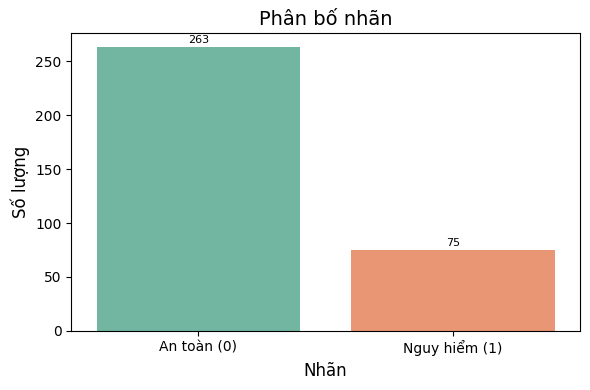

In [ ]:
import seaborn as sns
label_counts = df['label_risk'].value_counts().sort_index()

# Vẽ biểu đồ
plt.figure(figsize=(6, 4))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='Set2')

# Thêm chú thích
for i, count in enumerate(label_counts.values):
    plt.text(i, count + 2, f'{count}', ha='center', va='bottom', fontsize=8)

# Cài đặt tiêu đề và nhãn trục
plt.title('Phân bố nhãn', fontsize=14)
plt.xlabel('Nhãn', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['An toàn (0)', 'Nguy hiểm (1)'])

plt.tight_layout()
plt.show()

In [ ]:
print("🔍 Thông tin chung về dữ liệu:")
print(df.info())

🔍 Thông tin chung về dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 63 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   stock_code               338 non-null    object 
 1   company_name             338 non-null    object 
 2   establish_year           338 non-null    int64  
 3   current_debt_lag2        338 non-null    int64  
 4   current_debt_lag1        338 non-null    int64  
 5   current_debt_lag0        338 non-null    int64  
 6   earnings_power_lag2      338 non-null    float64
 7   earnings_power_lag1      338 non-null    float64
 8   earnings_power_lag0      338 non-null    float64
 9   enterprise_size_lag2     338 non-null    float64
 10  enterprise_size_lag1     338 non-null    float64
 11  enterprise_size_lag0     338 non-null    float64
 12  fin_leverage_lag2        338 non-null    float64
 13  fin_leverage_lag1        338 non-null    float64
 

In [ ]:
print("Thống kê mô tả dữ liệu số:")
print(df.describe())

Thống kê mô tả dữ liệu số:
       establish_year  current_debt_lag2  current_debt_lag1  \
count      338.000000       3.380000e+02       3.380000e+02   
mean      1993.236686       2.939845e+13       3.417451e+13   
std         16.296316       1.541845e+14       1.857436e+14   
min       1875.000000       1.257855e+09       1.351434e+09   
25%       1985.000000       2.107525e+11       2.008949e+11   
50%       1998.000000       7.025061e+11       7.507307e+11   
75%       2004.000000       2.720739e+12       2.872884e+12   
max       2018.000000       1.675367e+15       2.016419e+15   

       current_debt_lag0  earnings_power_lag2  earnings_power_lag1  \
count       3.380000e+02           338.000000           338.000000   
mean        3.900967e+13             0.054745             0.054134   
std         2.047243e+14             0.072353             0.125548   
min         1.312863e+09            -0.483408            -0.831684   
25%         1.917007e+11             0.016853          

In [ ]:
df.isnull().sum()

,0
stock_code,0
company_name,0
establish_year,0
current_debt_lag2,0
current_debt_lag1,0
...,...
label_2023,0
label_2022,0
label_2021,0
label_2024,0


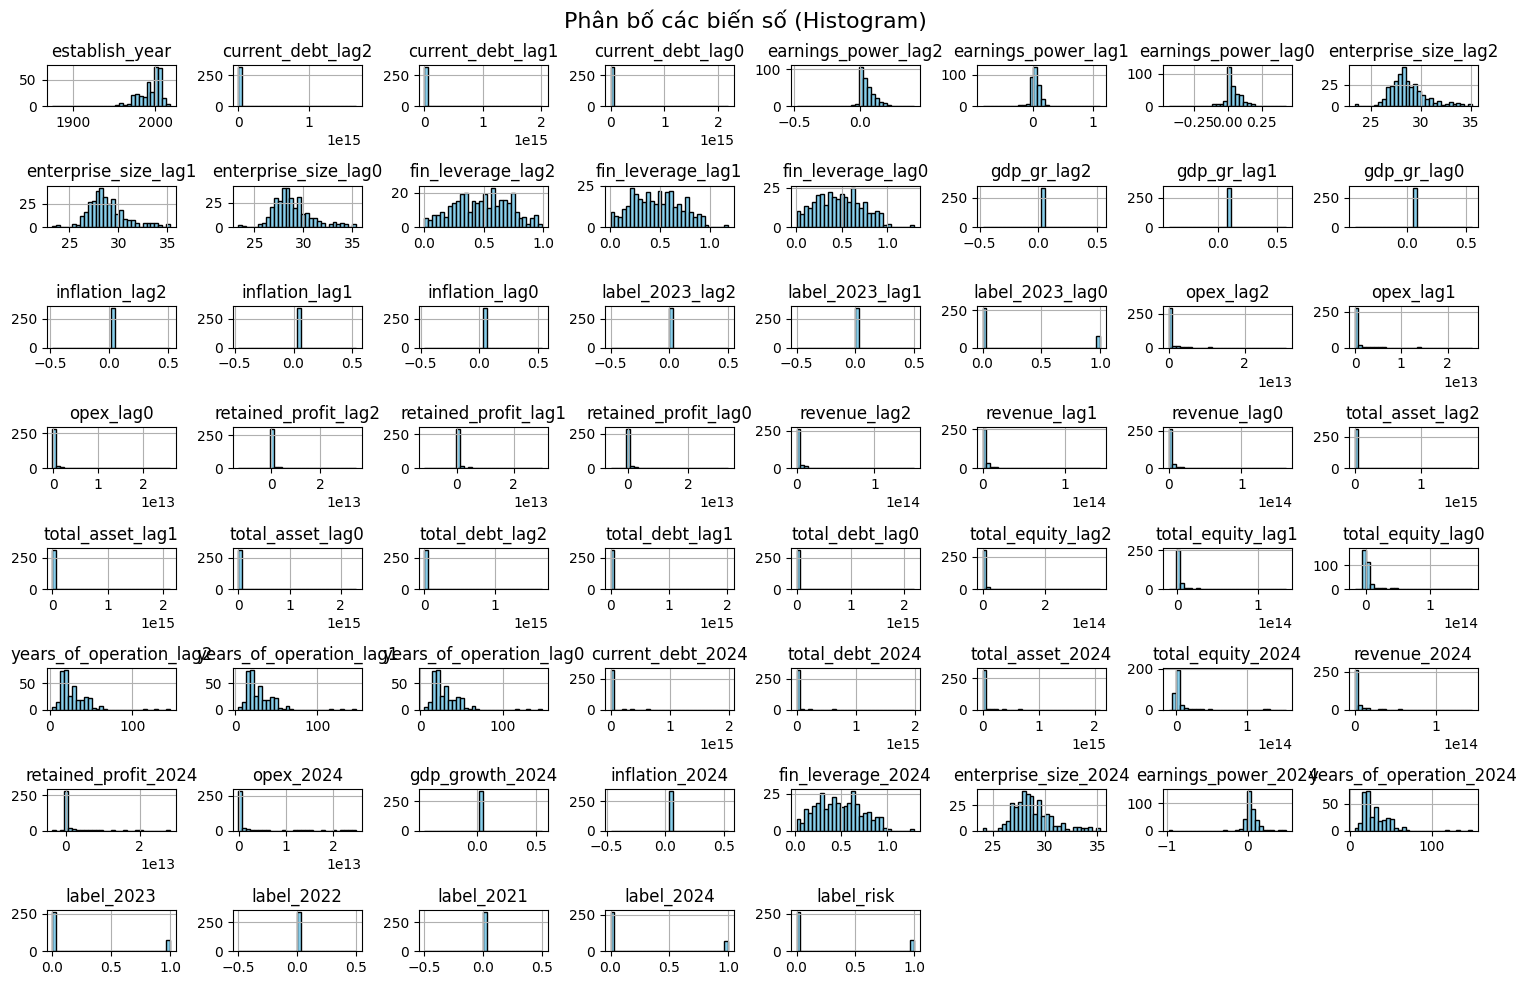

In [ ]:
# Phân bố từng biến
df.hist(figsize=(15, 10), bins=30, color='skyblue', edgecolor='black')
plt.suptitle("Phân bố các biến số (Histogram)", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

# Chọn các biến X và Y (tùy chỉnh theo dữ liệu của bạn)
X = df[['current_debt_lag0', 'current_debt_lag1', 'current_debt_lag2',
        'total_debt_lag0', 'total_debt_lag1', 'total_debt_lag2',
        'total_asset_lag0', 'total_asset_lag1', 'total_asset_lag2',
        'total_equity_lag0', 'total_equity_lag1', 'total_equity_lag2',
        'revenue_lag0', 'revenue_lag1', 'revenue_lag2',
        'retained_profit_lag0', 'retained_profit_lag1', 'retained_profit_lag2',
        'opex_lag0', 'opex_lag1', 'opex_lag2',
        'gdp_gr_lag0', 'gdp_gr_lag1', 'gdp_gr_lag2',
        'inflation_lag0', 'inflation_lag1', 'inflation_lag2',
        'fin_leverage_lag0', 'fin_leverage_lag1', 'fin_leverage_lag2',
        'enterprise_size_lag0', 'enterprise_size_lag1', 'enterprise_size_lag2',
        'earnings_power_lag0', 'earnings_power_lag1', 'earnings_power_lag2',
        'years_of_operation_lag0', 'years_of_operation_lag1', 'years_of_operation_lag2',
        'fin_leverage_2024', 'enterprise_size_2024', 'earnings_power_2024', 'years_of_operation_2024'
        ,'label_2021','label_2022']]
y = df['label_2023']

# Chia tập train-test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Khởi tạo và huấn luyện mô hình XGBoost
model_xgb = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, random_state=42)
model_xgb.fit(X_train, y_train)

# Đánh giá mô hình trên tập test
y_pred = model_xgb.predict(X_test)
y_proba = model_xgb.predict_proba(X_test)[:, 1]  # Xác suất lớp 1
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("AUC-ROC:", auc)
print(f"Độ chính xác trên tập test: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Dự báo label_2024
df['label_2024'] = model_xgb.predict(X)

AUC-ROC: 0.828125
Độ chính xác trên tập test: 0.82
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.94      0.89        52
           1       0.70      0.44      0.54        16

    accuracy                           0.82        68
   macro avg       0.77      0.69      0.71        68
weighted avg       0.81      0.82      0.81        68



In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler


# Chia tập train-test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuẩn hóa dữ liệu để SVM hoạt động tốt hơn
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Khởi tạo và huấn luyện mô hình SVM
model_svm = SVC(kernel='rbf', C=1.0, random_state=42, probability=True)  # kernel RBF, C=1.0 (mặc định)
model_svm.fit(X_train_scaled, y_train)

# Đánh giá mô hình trên tập test
y_pred = model_svm.predict(X_test_scaled)
y_proba = model_svm.predict_proba(X_test_scaled)[:, 1]  # Xác suất lớp 1
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("AUC-ROC:", auc)
print(f"Độ chính xác trên tập test: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Dự báo label_2024
df['label_2024'] = model_svm.predict(scaler.transform(X))

AUC-ROC: 0.8076923076923077
Độ chính xác trên tập test: 0.82
Classification Report:
               precision    recall  f1-score   support

           0       0.81      1.00      0.90        52
           1       1.00      0.25      0.40        16

    accuracy                           0.82        68
   macro avg       0.91      0.62      0.65        68
weighted avg       0.86      0.82      0.78        68



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Chia tập train-test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Khởi tạo và huấn luyện mô hình Random Forest
model_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model_rf.fit(X_train, y_train)

# Đánh giá mô hình trên tập test
y_pred = model_rf.predict(X_test)
y_proba = model_rf.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("AUC-ROC:", auc)
print(f"Độ chính xác trên tập test: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Dự báo label_2024
df['label_2024'] = model_rf.predict(X)

AUC-ROC: 0.8870192307692308
Độ chính xác trên tập test: 0.82
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.96      0.89        52
           1       0.75      0.38      0.50        16

    accuracy                           0.82        68
   macro avg       0.79      0.67      0.70        68
weighted avg       0.81      0.82      0.80        68



In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Chia tập train-test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Khởi tạo và huấn luyện mô hình Decision Tree
model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)  # Giới hạn độ sâu của cây để tránh overfitting
model_dt.fit(X_train, y_train)

# Đánh giá mô hình trên tập test
y_pred = model_dt.predict(X_test)
y_proba = model_dt.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("AUC-ROC:", auc)
print(f"Độ chính xác trên tập test: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Dự báo label_2024
df['label_2024'] = model_dt.predict(X)

AUC-ROC: 0.8419471153846154
Độ chính xác trên tập test: 0.84
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.96      0.90        52
           1       0.78      0.44      0.56        16

    accuracy                           0.84        68
   macro avg       0.81      0.70      0.73        68
weighted avg       0.83      0.84      0.82        68



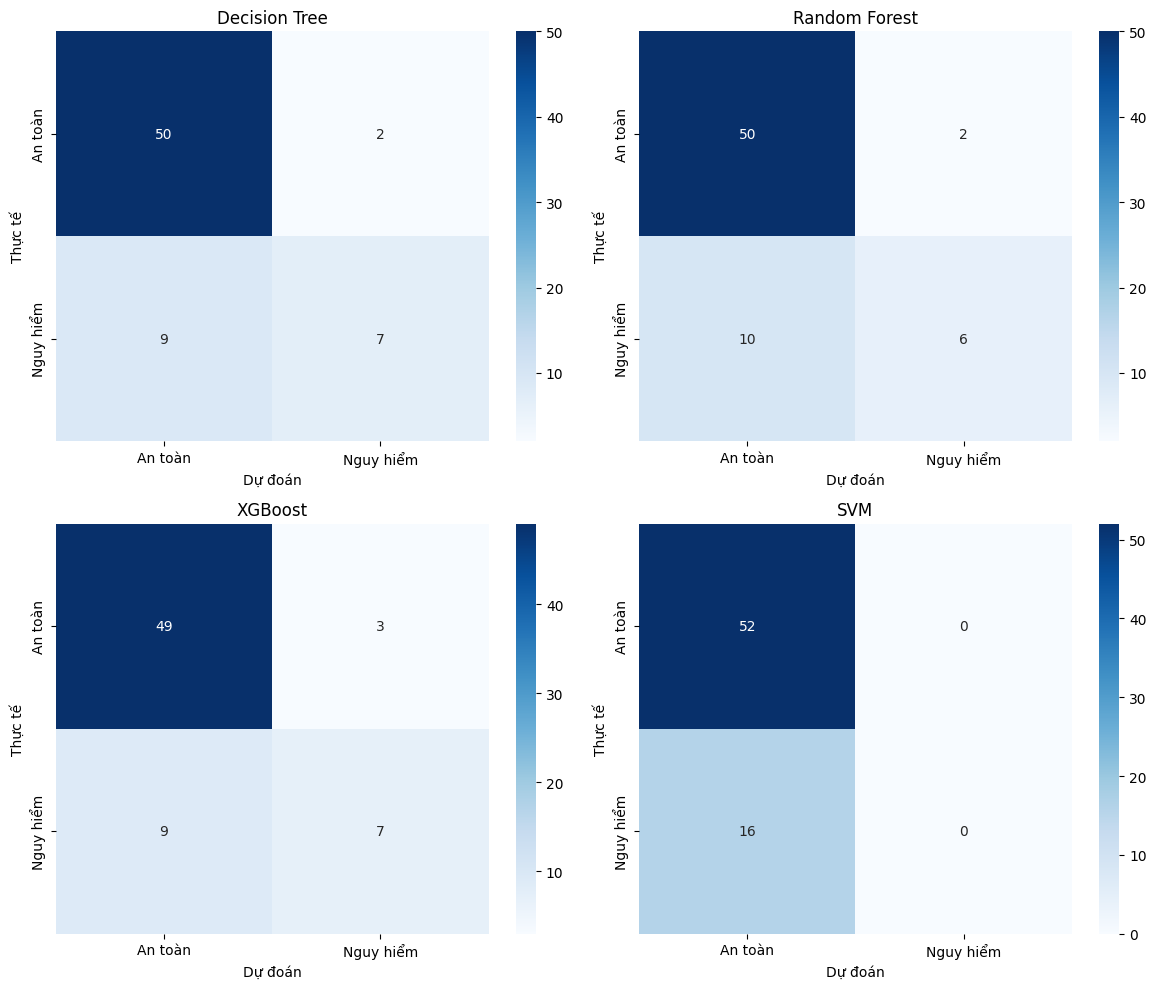

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Khởi chạy các mô hình
models = {"Decision Tree": model_dt, "Random Forest": model_rf, "XGBoost":model_xgb, "SVM":model_svm}
labels = ['An toàn', 'Nguy hiểm']

# Tạo figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Huấn luyện, dự đoán và vẽ ma trận nhầm lẫn
for ax, (name, model) in zip(axes.flatten(), models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Dự đoán")
    ax.set_ylabel("Thực tế")

#Vẽ ma trận nhầm lẫn
plt.tight_layout()
plt.show()


In [ ]:
# Hiệu chỉnh xác suất
calibrated_platt = CalibratedClassifierCV(model_dt, cv=5, method='sigmoid')
calibrated_platt.fit(X_train, y_train)
y_pred_proba_platt = calibrated_platt.predict_proba(X_test)[:, 1]

calibrated_isotonic = CalibratedClassifierCV(model_dt, cv=5, method='isotonic')
calibrated_isotonic.fit(X_train, y_train)
y_pred_proba_isotonic = calibrated_isotonic.predict_proba(X_test)[:, 1]

# Tính toán đường cong hiệu chỉnh
prob_true, prob_pred_uncal = calibration_curve(y_test, y_proba, n_bins=10, strategy='quantile')
prob_true_platt, prob_pred_platt = calibration_curve(y_test, y_pred_proba_platt, n_bins=10, strategy='quantile')
prob_true_isotonic, prob_pred_isotonic = calibration_curve(y_test, y_pred_proba_isotonic, n_bins=10, strategy='quantile')

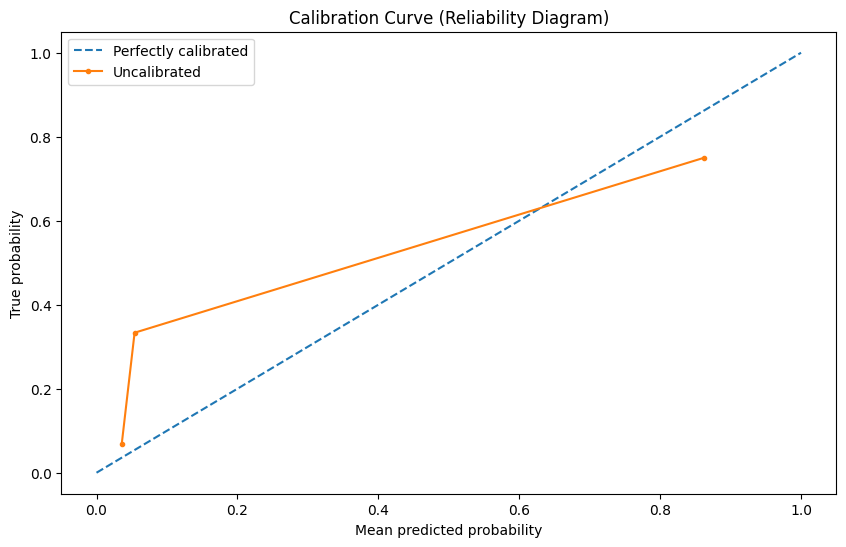

In [ ]:
# Vẽ biểu đồ Calibration Curve
plt.figure(figsize=(10, 6))
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
plt.plot(prob_pred_uncal, prob_true, marker='.', label='Uncalibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('True probability')
plt.title('Calibration Curve (Reliability Diagram)')
plt.legend()
plt.show()

In [ ]:
# Tính toán các chỉ số đánh giá mô hình
def compute_scores(y_true, y_pred_proba, name=None):
    scores = {
        'Brier Score': brier_score_loss(y_true, y_pred_proba),
        'Log Loss': log_loss(y_true, y_pred_proba),
        'AUC-ROC': roc_auc_score(y_true, y_pred_proba)
    }
    return pd.Series(scores).rename(name)

df_scores = pd.DataFrame([
    compute_scores(y_test, y_proba, name='Uncalibrated'),
    compute_scores(y_test, y_pred_proba_platt, name='Platt Scaling'),
    compute_scores(y_test, y_pred_proba_isotonic, name='Isotonic Regression')
])
print(df_scores)

                     Brier Score  Log Loss   AUC-ROC
Uncalibrated            0.135944  1.437333  0.841947
Platt Scaling           0.136161  0.433221  0.812500
Isotonic Regression     0.128795  0.415786  0.816106


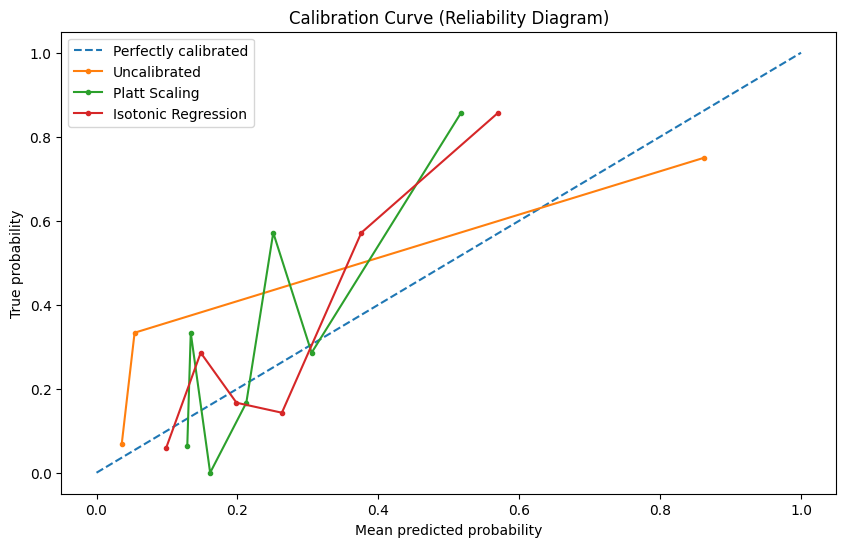

In [ ]:
# Vẽ biểu đồ Calibration Curve
plt.figure(figsize=(10, 6))
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
plt.plot(prob_pred_uncal, prob_true, marker='.', label='Uncalibrated')
plt.plot(prob_pred_platt, prob_true_platt, marker='.', label='Platt Scaling')
plt.plot(prob_pred_isotonic, prob_true_isotonic, marker='.', label='Isotonic Regression')
plt.xlabel('Mean predicted probability')
plt.ylabel('True probability')
plt.title('Calibration Curve (Reliability Diagram)')
plt.legend()
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Chia tập train-test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Khởi tạo và huấn luyện mô hình Decision Tree
model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)  # Giới hạn độ sâu của cây để tránh overfitting
model_dt.fit(X_train, y_train)

# Đánh giá mô hình trên tập test
y_pred = model_dt.predict(X_test)
y_proba = model_dt.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("AUC-ROC:", auc)
print(f"Độ chính xác trên tập test: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Dự báo label_2024
df['label_2024'] = model_dt.predict(X)

AUC-ROC: 0.8419471153846154
Độ chính xác trên tập test: 0.84
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.96      0.90        52
           1       0.78      0.44      0.56        16

    accuracy                           0.84        68
   macro avg       0.81      0.70      0.73        68
weighted avg       0.83      0.84      0.82        68



In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from scipy.stats import randint
# Điều chỉnh siêu tham số
param_dist = {
    "max_depth": [3, 5, 10, None],
    "max_features": randint(1, X.shape[1]),
    "min_samples_leaf": randint(1, 10),
    "criterion": ["gini", "entropy"]
}

tree = DecisionTreeClassifier(random_state=42)
tree_cv = RandomizedSearchCV(tree, param_distributions=param_dist, cv=5, n_iter=20, random_state=42)
tree_cv.fit(X_train, y_train)

# Đánh giá mô hình đã điều chỉnh
y_pred_tuned = tree_cv.predict(X_test)
acc_tuned = accuracy_score(y_test, y_pred_tuned)
print("Accuracy (sau khi điều chỉnh):", round(acc_tuned, 4))
print("Best Params:", tree_cv.best_params_)
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))

Accuracy (sau khi điều chỉnh): 0.7794
Best Params: {'criterion': 'gini', 'max_depth': 5, 'max_features': 2, 'min_samples_leaf': 8}

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.90      0.86        52
           1       0.55      0.38      0.44        16

    accuracy                           0.78        68
   macro avg       0.69      0.64      0.65        68
weighted avg       0.76      0.78      0.76        68



# **Feature Importance**

In [ ]:
# Lấy độ quan trọng các đặc trưng
importances = model_dt.feature_importances_

for i, v in enumerate(importances):
    print(f'Feature: {X.columns[i]}, Score: {v:.5f}')

Feature: current_debt_lag0, Score: 0.01991
Feature: current_debt_lag1, Score: 0.00000
Feature: current_debt_lag2, Score: 0.00000
Feature: total_debt_lag0, Score: 0.00000
Feature: total_debt_lag1, Score: 0.00000
Feature: total_debt_lag2, Score: 0.00000
Feature: total_asset_lag0, Score: 0.00000
Feature: total_asset_lag1, Score: 0.00000
Feature: total_asset_lag2, Score: 0.00000
Feature: total_equity_lag0, Score: 0.01991
Feature: total_equity_lag1, Score: 0.00000
Feature: total_equity_lag2, Score: 0.00000
Feature: revenue_lag0, Score: 0.00000
Feature: revenue_lag1, Score: 0.00000
Feature: revenue_lag2, Score: 0.00000
Feature: retained_profit_lag0, Score: 0.02810
Feature: retained_profit_lag1, Score: 0.08566
Feature: retained_profit_lag2, Score: 0.09578
Feature: opex_lag0, Score: 0.00000
Feature: opex_lag1, Score: 0.00000
Feature: opex_lag2, Score: 0.00000
Feature: gdp_gr_lag0, Score: 0.00000
Feature: gdp_gr_lag1, Score: 0.00000
Feature: gdp_gr_lag2, Score: 0.00000
Feature: inflation_lag0, 

In [ ]:
feature_names = X.columns
# Tạo DataFrame để dễ trực quan và xử lý
feat_imp_df = pd.DataFrame({'Chỉ số tài chính': feature_names, 'Tầm quan trọng': importances})
feat_imp_df = feat_imp_df.sort_values(by='Tầm quan trọng', ascending=False)

# Chỉ lấy các chỉ số có độ quan trọng đáng kể
important_features = feat_imp_df[feat_imp_df['Tầm quan trọng'] > 0.02]
print(f"Số lượng chỉ số tài chính thực sự quan trọng: {len(important_features)}")
print(important_features)

Số lượng chỉ số tài chính thực sự quan trọng: 8
           Chỉ số tài chính  Tầm quan trọng
33      earnings_power_lag0        0.484190
34      earnings_power_lag1        0.156867
17     retained_profit_lag2        0.095778
16     retained_profit_lag1        0.085655
38  years_of_operation_lag2        0.039812
15     retained_profit_lag0        0.028095
36  years_of_operation_lag0        0.027490
29        fin_leverage_lag2        0.022394


<ipython-input-194-56b4341e4c94>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tầm quan trọng', y='Chỉ số tài chính', data=important_features, palette='viridis')


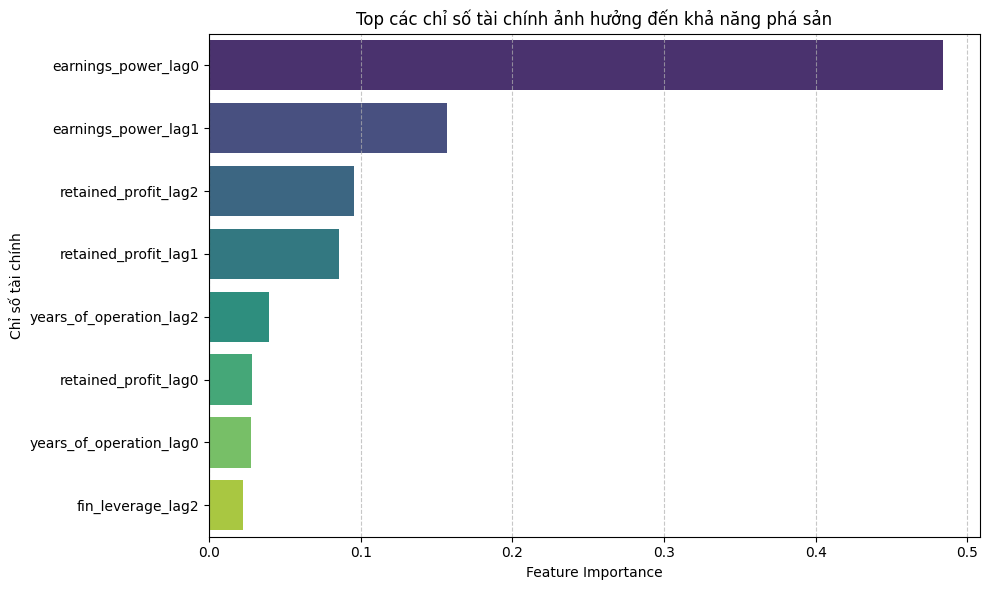

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Tầm quan trọng', y='Chỉ số tài chính', data=important_features, palette='viridis')
plt.title(f"Top các chỉ số tài chính ảnh hưởng đến khả năng phá sản")
plt.xlabel("Feature Importance")
plt.ylabel("Chỉ số tài chính")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
